# The Lorenz System: Chaos, in all its simplicity

**Jadan Kerr**

---

## 1. Introduction

Humans first wandered into the gilded halls of scientific thinking hundreds of years ago, and in all that time we've remained mostly illiterate in Nature's mother tongue of unpredictable chaotic flow. Our first words in this sacred language were uttered by Edward Lorenz in 1963. To describe the time evolution of a convective system he developed the **Lorenz system**, a simple family of ordinary differential equations that contained the characteristic and dazzling richness of what we now call chaotic dynamical systems. The system models intensity of convection on the x-axis, the horizontal temperature varation on the y-axis, and the derivation from a linear profile on the z-axis.

$$
\begin{aligned}
\dot{x} &= \sigma(y - x) \\
\dot{y} &= x(\rho - z) - y \\
\dot{z} &= xy - \beta z
\end{aligned}
$$

By plotting $x, y$, and $z$ as positions we can model the time evolution of the system as a trajectory in phase space.


Following the publishing of his paper "Deterministic Non-periodic flow" there was an immediate rise in interest in this new, strange study of chaos. The three related fields of dynamical systems theory, chaos theory, and fractals popped up and quickly enjoyed periods of rapid progress. The Lorenz system in particular found applications in all corners of science and physics, from atmospheric modeling to plasma physics and optics.

The particular attractor we're studying today is known simply as the Lorenz Attractor, or Lorenz Butterfly. The attractor is the set of points that any initial starting condition tends towards as $t \rightarrow \infty$. The Lorenz attractor is the attractor when $\sigma = 10$ , $\rho = 28$,  $\beta = \frac{8}{3}$. In this project we model the Lorenz system using three different algorithms, and cross-compare the difference in solutions.

## 2. Methods

Two solvers were developed for this project, one utilizing Euler's algorith, and one using the famous Runge-Kutta 4 approach of numerical integration. `solve_ivp` from scipy.integrate was also implemented as the best-case-scenario approach.


### Euler's Algorithm
Euler's method of numerical integration is extremely simple. Given a set of initial conditions $(x_0,y_0,z_0)$ and function $f'(x,y,z)$, we know everything about a particle's instantaneous position and velocity. Since we don't expect the velocity to change dramatically over a tiny difference in position, we take $f'(x,y,z)$ to be constant over some small time step, dt. We see what the new position of the particle would be after dt with the calculated velocity, and rinse and repeat. After taking a large enough quantity of small enough time steps, we begin to approximate truly continuous position and velocity updates.

$$f(x)_{n+1} = f(x)_n + \Delta t \cdot f'(t_n, x_n)$$


In `tools.py` Euler's algorithm is implemented in the `LorenzSystem` class as `lorenz_sim_euler(...)`

### Runge-Kutta 4th order
The Runge-Kutta method involves essentially the same steps as the Euler algorithm, with 1 key difference. Rather than taking one value of $f'(x)$ and assuming it stays invariant over a small time interval dt, we take multiple different samples of f' at different points inside the dt interval. In particular we take two values at the middle, and two values at the endpoints. We compute the weighted average of these four values and use this to step forward in time.

$$
\begin{aligned}
k_1 &= f(t_n, x_n) \\
k_2 &= f\left(t_n + \frac{1}{2}\Delta t,\; x_n + \frac{1}{2}\Delta t\, k_1\right) \\
k_3 &= f\left(t_n + \frac{1}{2}\Delta t,\; x_n + \frac{1}{2}\Delta t\, k_2\right) \\
k_4 &= f\left(t_n + \Delta t,\; x_n + \Delta t\, k_3\right)
\end{aligned}
$$


The update is then:

$$
x_{n+1} = x_n + \frac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right).
$$

The weights $(1,2,2,1)$ give a local truncation error of order $\Delta t^5$, so the global error scales as $\Delta t^4$.

In `tools.py` the RK 4 algorithm is implemented in the `LorenzSystem` class as `lorenz_sim_rk(...)`



### `solve_ivp` from scipy.integrate
We used the solve_ivp method from the scipy library as a baseline "best case scenario" approach to numerically integrating the Lorenz system. The function essentially consists of an RK4 implementation with variable time resolution. The documentation states that the error is controlled assuming accuracy of the fourth-order method, but steps are taken using the fifth-order accurate formula.

In `tools.py` `solve_ivp` is implemented in the `LorenzSystem` class as `lorenz_solve_ivp(...)`



## 3. Results

We first import the libraries we need and the `LorenzSystem` class from `tools.py`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tools import LorenzSystem



### 3.1 Lorenz Attractor using RK4, Euler's method, and solve_ivp

For the first scenario we take a particle with initial positions $x_0 = .1$ , $y_0 = 1$ , $z_0 = 2$. We use a time step $\Delta t = 10^{-4}$ s and run the simulation for 100 seconds. We compare visually the structure and trajectory distributions of the Lorenz attractor as plotted by LorenzSystem's `lorenz_sim_rk`, `lorenz_sim_euler`, and `lorenz_solve_ivp`

We expect to see the classic "Lorenz Butterfly" plotted in 3d.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tools import LorenzSystem

l = LorenzSystem()
x0, y0, z0 = 0.1, 1, 2
points = l.lorenz_sim_rk(x0, y0, z0, 100, 1e-4)
points_e = l.lorenz_sim_euler(x0, y0, z0, 100, 1e-4)
points_ivp = l.lorenz_solve_ivp(x0, y0, z0, 100, 50001, 1e-10, 1e-12).y.T


plt.style.use('dark_background')

# Create figure with 1 row, 3 columns of 3D subplots
fig = plt.figure(figsize=(18, 6))

# First subplot (points)
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.grid(linewidth=0.05, alpha=0.2)
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')

x, y, z = zip(*points)
ax1.plot(x, y, z, lw=0.25, c='orange')
ax1.set_title('Fig A: Lorenz attractor (RK4 method)')

# Second subplot (points_e)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.grid(linewidth=0.05, alpha=0.2)
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')

x_e, y_e, z_e = zip(*points_e)
ax2.plot(x_e, y_e, z_e, lw=0.25, c='orange')
ax2.set_title('Fig B: Lorenz attractor (Euler method)')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.grid(linewidth=0.05, alpha=0.2)
for axis in [ax3.xaxis, ax3.yaxis, ax3.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')

x_f, y_f, z_f = zip(*points_ivp) 
ax3.plot(x_f, y_f, z_f, lw=0.25, c='orange')
ax3.set_title('Fig C: Lorenz attractor (solve_ivp implementation)')

plt.tight_layout()
plt.show()


*Discussion:* The two methods(Fig 3.1(a), and (b))  give similar looking shapes, but interestingly it's immediately obvious that they are fundamentally different in structure and trajectory distribution. Fig 3.1(c) shows a plot using solve_ivp which visually matches the RK4 approach, so we can rule out the differences due to chaotic instability. What we see is error inherent in the Euler approach itself.

### 3.2 Sensitivity to initial conditions

One of the properties of chaotic dynamical systems is their extreme sensitivity to initial conditions. This is a graph comparing the absolute positions of two nearly-identical Lorenz systems, with one catch: We change the initial condition by a factor of 1e-9 on the second system. 

In [33]:
x0,y0,z0 = 0.1, 1, 2
p1 = l.lorenz_sim_rk(x0,y0,z0, 50, 1e-4)
p2 = l.lorenz_sim_rk(x0 + 1e-9,y0,z0, 50, 1e-4)
delta = np.abs(np.array(p1) - np.array(p2))



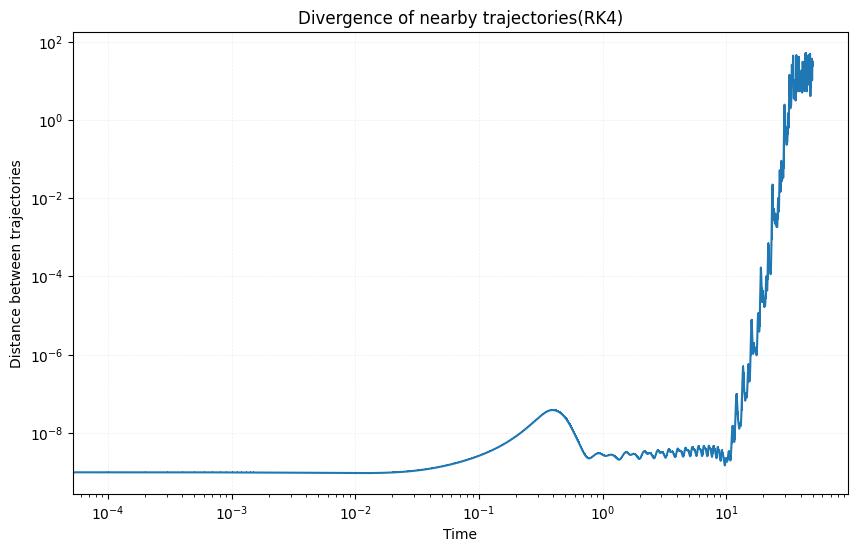

In [34]:
delta.shape
delta_n = (np.sum(delta**2, axis = 1)**0.5)
xs = np.linspace(0,50,delta.shape[0])
plt.style.use('default')
plt.figure(figsize = (10,6))
plt.loglog(xs, delta_n, marker = ',')
plt.title('Divergence of nearby trajectories(RK4)')
plt.xlabel('Time')
plt.ylabel('Distance between trajectories')
plt.grid(True, which='major', ls='--', lw=0.5, alpha=0.2)
plt.show()


Given an arbitrarily small difference in initial conditions, the state of the system will eventually diverge wildly. It's interesting to note the oscillatory behavior as the particle orbits around and around the center of the attractor. There's also an anomalous hump right around $t \approx 10^{-1/2}$ where the two trajectories diverge then come back to much closer agreement. Our one possible explanation for this is the particle's known tendency to "hop" between the two wings of the butterfly. We suggest the two particle's trajectories diverged when one particle crossed to the opposite wing, where it swirled briefly before rejoining its sibling back on the original wing.

## 4. Conclusions

We wrote two algorithms for solving the Lorenz system of ordinary differential equations, and used a third additional algorithm as a baseline. We then compared the differences between these three approaches, as well as confirming the sensitivity to initial conditions of chaotic dynamical systems. 

## References

- Lorenz, E. N. (1963). Deterministic nonperiodic flow. *Journal of the Atmospheric Sciences*, 20(2), 130–141.

- Alexander, M. Numerical solution of the Lorenz equations with spatial inhomogeneity.

- Guckenheimer, J., & Williams, R. F. (1979). Structural stability of Lorenz attractors. *Publications Mathématiques de l'Institut des Hautes Études Scientifiques*, 50(1), 59–72.

- Hirsch, M. W., Smale, S., & Devaney, R. L. (2012). *Differential equations, dynamical systems, and an introduction to chaos* (3rd ed.). Academic Press.
